# 01 — Khám phá dữ liệu RAVDESS
EDA: phân phối nhãn, plot waveform, thống kê độ dài file.

**Phụ trách:** Linh

In [9]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

# Đường dẫn dataset
DATA_DIR = Path('../data/ravdess')

# Mapping nhãn cảm xúc theo RAVDESS
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

In [10]:
records=[]

for actor_dir in sorted(DATA_DIR.iterdir()):
    if not actor_dir.is_dir():
        continue
    for wav_file in sorted(actor_dir.glob('*.wav')):
        parts = wav_file.stem.split('-')
        # Tên file: modality-vocal_channel-emotion-intensity-statement-repetition-actor
        emotion_code = parts[2]
        emotion_label = EMOTION_MAP.get(emotion_code, 'unknown')
        actor_id = parts[6]
        
        try:
            duration = librosa.get_duration(path=str(wav_file))
        except Exception:
            duration = None
        
        records.append({
            'file': wav_file.name,
            'actor': actor_dir.name,
            'emotion_code': emotion_code,
            'emotion': emotion_label,
            'duration': duration
        })

df = pd.DataFrame(records)
print(f'Tổng số file: {len(df)}')
print(f'Số actor: {df["actor"].nunique()}')
print(f'Số nhãn: {df["emotion"].nunique()}')
df.head()

Tổng số file: 1440
Số actor: 24
Số nhãn: 8


,file,actor,emotion_code,emotion,duration
0,03-01-01-01-01-01-01.wav,Actor_01,01,neutral,3.303292
1,03-01-01-01-01-02-01.wav,Actor_01,01,neutral,3.336667
2,03-01-01-01-02-01-01.wav,Actor_01,01,neutral,3.269917
3,03-01-01-01-02-02-01.wav,Actor_01,01,neutral,3.169833
4,03-01-02-01-01-01-01.wav,Actor_01,02,calm,3.536854


In [12]:
label_counts = df['emotion'].value_counts().reindex(EMOTION_MAP.values())
print('Số lượng mẫu theo từng nhãn:')
print(label_counts.to_string())
print(f'Tổng: {label_counts.sum()}')
print(f'Tỉ lệ (%): min={label_counts.min()/len(df)*100:.1f}%, max={label_counts.max()/len(df)*100:.1f}%')

Số lượng mẫu theo từng nhãn:
emotion
neutral       96
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
Tổng: 1440
Tỉ lệ (%): min=6.7%, max=13.3%


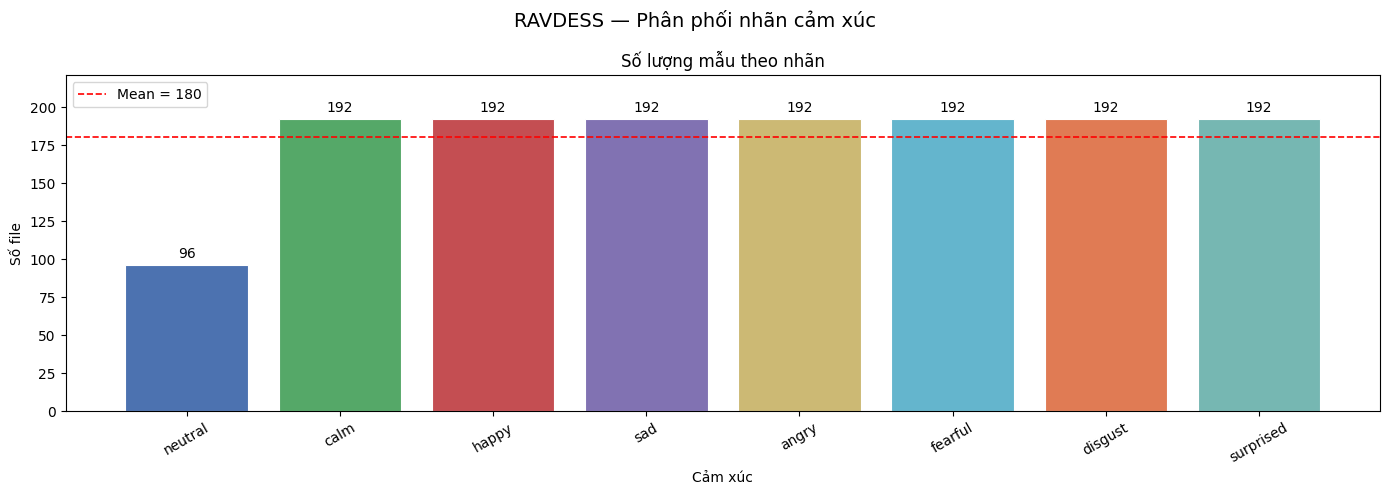

In [24]:
COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD','#E07B54','#76B7B2']

fig, ax = plt.subplots(figsize=(14, 5))  # nhận đủ 2 biến: fig và ax
fig.suptitle('RAVDESS — Phân phối nhãn cảm xúc', fontsize=14)

bars = ax.bar(label_counts.index, label_counts.values, color=COLORS, edgecolor='white', linewidth=0.8)
ax.set_title('Số lượng mẫu theo nhãn')
ax.set_xlabel('Cảm xúc')
ax.set_ylabel('Số file')
ax.tick_params(axis='x', rotation=30)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

mean_val = label_counts.mean()
ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean = {mean_val:.0f}')
ax.legend()
ax.set_ylim(0, label_counts.max() * 1.15)

plt.tight_layout()
plt.show()

In [25]:
dur = df['duration'].dropna()

print(' Thống kê Duration (giây)')
print(f'Min   : {dur.min():.3f}s')
print(f'Max   : {dur.max():.3f}s')
print(f'Mean  : {dur.mean():.3f}s')
print(f'Median: {dur.median():.3f}s')
print(f'Std   : {dur.std():.3f}s')

# Duration theo từng nhãn
print('Duration trung bình theo nhãn:')
print(df.groupby('emotion')['duration'].agg(['min','max','mean']).round(3).to_string())

 Thống kê Duration (giây)
Min   : 2.936s
Max   : 5.272s
Mean  : 3.701s
Median: 3.670s
Std   : 0.337s
Duration trung bình theo nhãn:
             min    max   mean
emotion                       
angry      3.237  5.105  3.871
calm       2.936  4.771  3.796
disgust    3.136  5.272  3.942
fearful    3.070  5.005  3.574
happy      3.103  4.404  3.638
neutral    3.070  4.137  3.503
sad        3.103  4.738  3.694
surprised  2.970  4.638  3.488


/var/folders/2r/vw2t59sn3pq2xsn2gn9892fc0000gn/T/ipykernel_74088/310357931.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_emotion, labels=emotion_order, patch_artist=True)


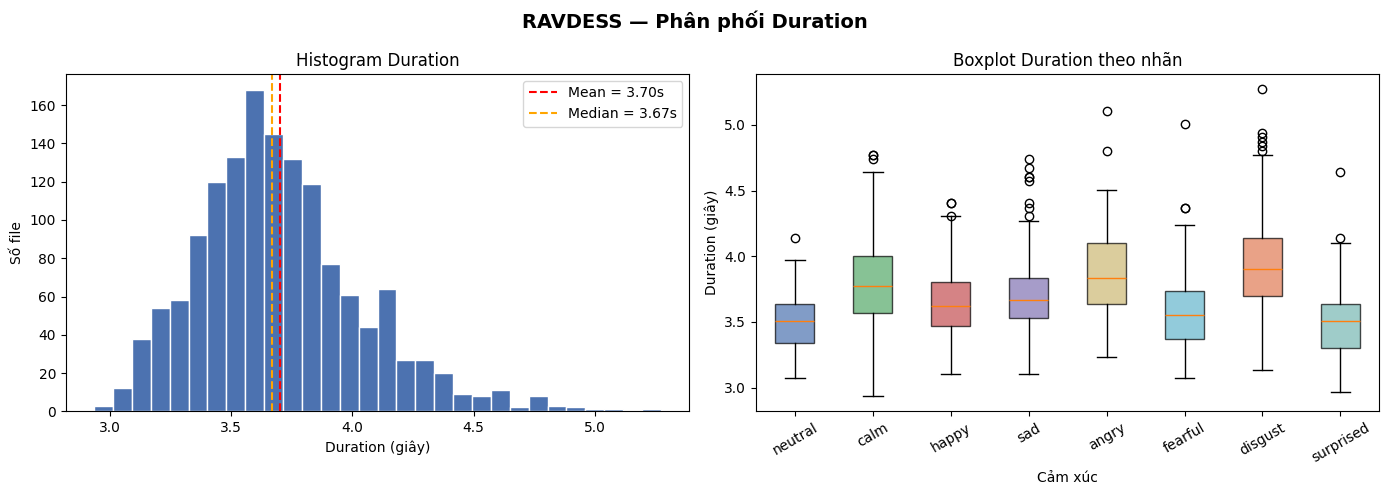

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RAVDESS — Phân phối Duration', fontsize=14, fontweight='bold')

# Histogram tổng
axes[0].hist(dur, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(dur.mean(), color='red', linestyle='--', label=f'Mean = {dur.mean():.2f}s')
axes[0].axvline(dur.median(), color='orange', linestyle='--', label=f'Median = {dur.median():.2f}s')
axes[0].set_title('Histogram Duration')
axes[0].set_xlabel('Duration (giây)')
axes[0].set_ylabel('Số file')
axes[0].legend()

# Boxplot theo nhãn
emotion_order = list(EMOTION_MAP.values())
data_by_emotion = [df[df['emotion'] == e]['duration'].dropna().values for e in emotion_order]
bp = axes[1].boxplot(data_by_emotion, labels=emotion_order, patch_artist=True)
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Boxplot Duration theo nhãn')
axes[1].set_xlabel('Cảm xúc')
axes[1].set_ylabel('Duration (giây)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../report/figures/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
total = len(df)
pcts = (label_counts / total * 100).round(2)
imbalance_ratio = label_counts.max() / label_counts.min()

print('=' * 50)
print('NHẬN XÉT CLASS IMBALANCE')
print('=' * 50)
print(f'\nTỉ lệ mẫu từng nhãn:')
for emotion, pct in pcts.items():
    bar = '█' * int(pct / 2)
    print(f'  {emotion:<10} {pct:5.1f}%  {bar}')

print(f'Imbalance ratio (max/min): {imbalance_ratio:.2f}x')

print('--- Kết luận ---')
if imbalance_ratio < 1.5:
    print('Dataset cân bằng')
elif imbalance_ratio < 3.0:
    print('Dataset hơi mất cân bằng')
else:
    print('Dataset mất cân bằng nặng')

print(f'neutral (01) thường có ít mẫu hơn vì RAVDESS chỉ có 1 intensity cho neutral.')

NHẬN XÉT CLASS IMBALANCE

Tỉ lệ mẫu từng nhãn:
  neutral      6.7%  ███
  calm        13.3%  ██████
  happy       13.3%  ██████
  sad         13.3%  ██████
  angry       13.3%  ██████
  fearful     13.3%  ██████
  disgust     13.3%  ██████
  surprised   13.3%  ██████
Imbalance ratio (max/min): 2.00x
--- Kết luận ---
Dataset hơi mất cân bằng
neutral (01) thường có ít mẫu hơn vì RAVDESS chỉ có 1 intensity cho neutral.


In [30]:
summary = pd.DataFrame({
    'Số mẫu': label_counts,
    'Tỉ lệ (%)': pcts,
    'Duration min (s)': df.groupby('emotion')['duration'].min().round(3),
    'Duration max (s)': df.groupby('emotion')['duration'].max().round(3),
    'Duration mean (s)': df.groupby('emotion')['duration'].mean().round(3),
})
summary = summary.reindex(EMOTION_MAP.values())
print('Bảng tổng hợp:')
print(summary.to_string())

# Lưu CSV
summary.to_csv('../experiments/eda_summary.csv')

Bảng tổng hợp:
           Số mẫu  Tỉ lệ (%)  Duration min (s)  Duration max (s)  Duration mean (s)
emotion                                                                            
neutral        96       6.67             3.070             4.137              3.503
calm          192      13.33             2.936             4.771              3.796
happy         192      13.33             3.103             4.404              3.638
sad           192      13.33             3.103             4.738              3.694
angry         192      13.33             3.237             5.105              3.871
fearful       192      13.33             3.070             5.005              3.574
disgust       192      13.33             3.136             5.272              3.942
surprised     192      13.33             2.970             4.638              3.488
